In [ ]:
%pip install catboost scikit-learn rdkit

In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
raw = pd.read_csv("sample_data/physical_chemical_properties_of_organic_substances.csv")
raw.head()

In [ ]:
properties = raw[['name', 'smiles']].copy()
properties = properties[properties['smiles'].notna()]
properties['MolWt'] = properties['smiles'].apply(lambda x: Descriptors.MolWt(Chem.MolFromSmiles(x)))
properties['HeavyAtomCount'] = properties['smiles'].apply(lambda x: Descriptors.HeavyAtomCount(Chem.MolFromSmiles(x)))
properties['MolLogP'] = properties['smiles'].apply(lambda x: Descriptors.MolLogP(Chem.MolFromSmiles(x)))
properties['TPSA'] = properties['smiles'].apply(lambda x: Descriptors.TPSA(Chem.MolFromSmiles(x)))
properties['NumHDonors'] = properties['smiles'].apply(lambda x: Descriptors.NumHDonors(Chem.MolFromSmiles(x)))
properties['NumHAcceptors'] = properties['smiles'].apply(lambda x: Descriptors.NumHAcceptors(Chem.MolFromSmiles(x)))
properties['NumAromaticRings'] = properties['smiles'].apply(lambda x: Descriptors.NumAromaticRings(Chem.MolFromSmiles(x)))
properties['NumRotatableBonds'] = properties['smiles'].apply(lambda x: Descriptors.NumRotatableBonds(Chem.MolFromSmiles(x)))
properties['NumHeteroatoms'] = properties['smiles'].apply(lambda x: Descriptors.NumHeteroatoms(Chem.MolFromSmiles(x)))
properties['melting_point_K'] = raw['melting_point_K']
properties['boiling_point_K'] = raw['boiling_point_K']
properties['heat_of_fusion'] = raw['heat_of_fusion']
properties['heat_of_vaporization'] = raw['heat_of_vaporization']
properties['critical_temperature'] = raw['critical_temperature']
properties['critical_pressure'] = raw['critical_pressure']
properties['flash_point'] = raw['flash_point']
properties.head()

0:	learn: 62.3787418	test: 57.8866210	best: 57.8866210 (0)	total: 1.57ms	remaining: 15.7s
2000:	learn: 0.2088973	test: 32.1998308	best: 31.1126588 (92)	total: 2.33s	remaining: 9.31s
4000:	learn: 0.0065890	test: 32.2191822	best: 31.1126588 (92)	total: 6.07s	remaining: 9.1s
6000:	learn: 0.0002387	test: 32.2195868	best: 31.1126588 (92)	total: 6.84s	remaining: 4.56s
8000:	learn: 0.0000107	test: 32.2196136	best: 31.1126588 (92)	total: 7.43s	remaining: 1.86s
9999:	learn: 0.0000005	test: 32.2196141	best: 31.1126588 (92)	total: 8.04s	remaining: 0us

bestTest = 31.11265876
bestIteration = 92

Shrink model to first 93 iterations.
Testing performance
RMSE: 31.11
R2: 0.74


Text(0.5, 1.0, 'Actual vs Predicted')

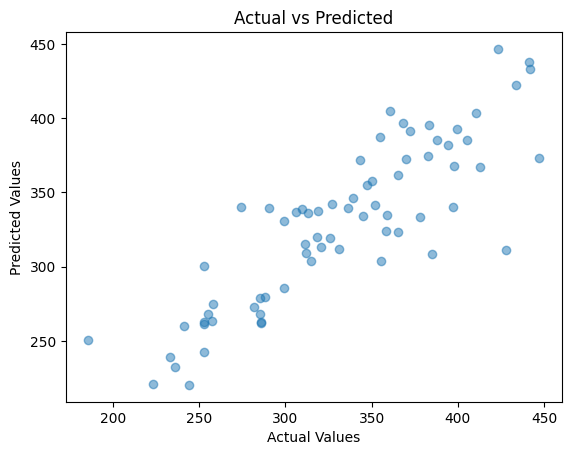

In [7]:
properties = properties[properties['flash_point'].notna()]
X = properties.drop(columns=['name', 'smiles', 'melting_point_K', 'boiling_point_K', 'heat_of_fusion', 'heat_of_vaporization', 'critical_temperature', 'critical_pressure', 'flash_point'])
y = properties['flash_point']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = CatBoostRegressor(iterations=10000, learning_rate=0.1, depth=4, verbose=2000, loss_function='RMSE')
model.fit(X_train, y_train, eval_set=(X_test, y_test))
predictions = model.predict(X_test)

rmse = (np.sqrt(mean_squared_error(y_test, predictions)))
r2 = r2_score(y_test, predictions)
print("Testing performance")
print('RMSE: {:.2f}'.format(rmse))
print('R2: {:.2f}'.format(r2))

plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
